In [2]:
import time
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d, spinless_fermion_basis_1d, ho_basis, tensor_basis, boson_basis_1d
from quspin.tools.evolution import evolve
import scipy.sparse.linalg as splinalg  
from scipy import sparse
import matplotlib.pyplot as plt
import qutip as qt
from tqdm import tqdm 

### ----------------------------------------------------------

In [3]:
# Electron-phonon coupling function------------------------------------
def g(i,mu):
    return (8/(np.pi*mu**(3/2)))*np.sin((2*i+1)*np.pi*mu/8)*np.sin(np.pi*mu/8)

# Used Operators in Hamiltonian------------------------------------------
def shifted_phonon_number_operator_A(basis_electron_phonon):
    shifted_phonon_number_operator_A = hamiltonian(
        [
            ['||||n', [[1, 0]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return shifted_phonon_number_operator_A

def shifted_phonon_number_operator_B(basis_electron_phonon):
    shifted_phonon_number_operator_B = hamiltonian(
        [
            ['||||n', [[1, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return shifted_phonon_number_operator_B

def shifted_phonon_a_operator_A(basis_electron_phonon):
    shifted_phonon_a_operator_A = hamiltonian(
        [
            ['||||-', [[1, 0]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return shifted_phonon_a_operator_A

def shifted_phonon_a_operator_B(basis_electron_phonon):
    shifted_phonon_a_operator_B = hamiltonian(
        [
            ['||||-', [[1, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return shifted_phonon_a_operator_B

def shifted_phonon_adag_operator_A(basis_electron_phonon):
    shifted_phonon_adag_operator_A = hamiltonian(
        [
            ['||||+', [[1, 0]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return shifted_phonon_adag_operator_A

def shifted_phonon_adag_operator_B(basis_electron_phonon):
    shifted_phonon_adag_operator_B = hamiltonian(
        [
            ['||||+', [[1, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return shifted_phonon_adag_operator_B

def shift_parameter_operator_init_A(basis_electron_2tubes, g0_A, omega_A, mu_A):
    shift_parameter_operator_init_A = hamiltonian(
        [
            ['|n||', [[g(i,mu_A)*g0_A / omega_A, i] for i in range(L)]],
            ['n|||', [[g(i,mu_A)*g0_A / omega_A, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_2tubes,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return shift_parameter_operator_init_A

def shift_parameter_operator_init_B(basis_electron_2tubes,g0_B,omega_B,mu_B):
    shift_parameter_operator_init_B = hamiltonian(
         [
             ['|||n', [[g(i,mu_B)*g0_B / omega_B, i] for i in range(L)]],
             ['||n|', [[g(i,mu_B)*g0_B / omega_B, i] for i in range(L)]],
         ],
         [],
         basis=basis_electron_2tubes,
         dtype=np.complex128,
         check_pcon=False,check_symm=False,check_herm=False
     )
    return shift_parameter_operator_init_B

def electron_number_operator_ep_A(basis_electron_phonon,L):
    electron_number_operator_ep_A = hamiltonian(
        [
            ['n|n|||', [[1, i, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return electron_number_operator_ep_A

def electron_number_operator_ep_B(basis_electron_phonon,L):
    electron_number_operator_ep_B = hamiltonian(
        [
            ['||n|n|', [[1, i, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return electron_number_operator_ep_B

def electron_number_operator_e_A(basis_electron_2tubes,L):
    electron_number_operator_e_A = hamiltonian(
        [
            ['n|n||', [[1, i, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_2tubes,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return electron_number_operator_e_A

def electron_number_operator_e_B(basis_electron_2tubes,L):
    electron_number_operator_e_B = hamiltonian(
        [
            ['||n|n', [[1, i, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_2tubes,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return electron_number_operator_e_B

def phonon_number_A(psi_GS, shift_parameter0):
    n = np.real(
            shifted_phonon_number_operator_A.expt_value(psi_GS) \
                + np.conj(shift_parameter0) * shifted_phonon_a_operator_A.expt_value(psi_GS) \
                    + shift_parameter0 * shifted_phonon_adag_operator_A.expt_value(psi_GS) \
                        + shift_parameter0 * np.conj(shift_parameter0)
        )
    return n

def phonon_number_B(psi_GS, shift_parameter0):
    n = np.real(
            shifted_phonon_number_operator_B.expt_value(psi_GS) \
                + np.conj(shift_parameter0) * shifted_phonon_a_operator_B.expt_value(psi_GS) \
                    + shift_parameter0 * shifted_phonon_adag_operator_B.expt_value(psi_GS) \
                        + shift_parameter0 * np.conj(shift_parameter0)
        )
    return n

# Charge Correlation: Inside one Tube--------------------------------
def charge_corr_singletube_A(basis_electron_phonon, psi_GS,L):
    def charge_single_A(i):
        h = hamiltonian(
            [
                # Number operator
                ['n||||', [[1, i]]],
                ['|n|||', [[1, i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h

    def charge_both_single_A(i,j):
        h = hamiltonian(
            [
                # Number operator
                ['nn||||', [[1, i,j]]],
                ['|nn|||', [[1, i,j]]],
                ['n|n|||', [[1, i,j]]],
                ['n|n|||', [[1, j,i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h
    
    CC_single = 0
    for i in range(L):
        for j in range(i+1):
            CC_single += np.real(charge_both_single_A(i,j).expt_value(psi_GS)-charge_single_A(i).expt_value(psi_GS)*charge_single_A(j).expt_value(psi_GS))
    CC_single /= 4
    return CC_single
   
def charge_corr_singletube_B(basis_electron_phonon, psi_GS,L):
    def charge_single_B(i):
        h = hamiltonian(
            [
                # Number operator
                ['||n||', [[1, i]]],
                ['|||n|', [[1, i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h

    def charge_both_single_B(i,j):
        h = hamiltonian(
            [
                # Number operator
                ['||nn||', [[1, i,j]]],
                ['|||nn|', [[1, i,j]]],
                ['||n|n|', [[1, i,j]]],
                ['||n|n|', [[1, j,i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h

    CC_single = 0
    for i in range(L):
        for j in range(i+1):
            CC_single += np.real(charge_both_single_B(i,j).expt_value(psi_GS)-charge_single_B(i).expt_value(psi_GS)*charge_single_B(j).expt_value(psi_GS))
    CC_single /= 4
    return CC_single


# Charge Correlation: Between Tubes ----------------------------------
def charge_corr_between(basis_electron_phonon, psi_GS,L):
    def charge_both_dT(i,j): #first index: Tube1, second Index: Tube 2
        op = hamiltonian(
            [
                ['n||n||', [[1, i, j]]],
                ['n|||n|', [[1, i, j]]],
                ['|n|n||', [[1, i, j]]],
                ['|n||n|', [[1, i, j]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return op
        
    def charge_dt(m,i): #m: Index of Tube{0,1}; i: Index of Site
        if m == 0:
            op = hamiltonian(
                [
                    ['n||||', [[1, i]]],
                    ['|n|||', [[1, i]]],
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
            return op
        op = hamiltonian(
            [
                ['||n||', [[1, i]]],
                ['|||n|', [[1, i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return op

    CC_dT = 0
    for i in range(L): #Tube1
        for j in range(L): #Tube2
            CC_dT += np.real(charge_both_dT(i,j).expt_value(psi_GS)-charge_dt(0,i).expt_value(psi_GS)*charge_dt(1,j).expt_value(psi_GS))
    return CC_dT

In [4]:
def hamiltonian_noshift(omega_A, omega_B, epsilon_A, epsilon_B, t_A, t_B, V, g0_A, g0_B,L,mu,basis_electron_phonon):
    H = hamiltonian(
        [
            ## phonon part
            # Tube A
            ['||||n', [[omega_A, 0]]],
            # Tube B
            ['||||n', [[omega_B, 1]]],
            ## electron part
            # hopping terms - Tube A
            ['+-||||', [[-t_A, i, i+1] for i in range(L-1)]],
            ['-+||||', [[+t_A, i, i+1] for i in range(L-1)]],
            ['|+-|||', [[-t_A, i, i+1] for i in range(L-1)]],
            ['|-+|||', [[+t_A, i, i+1] for i in range(L-1)]],
            # hopping terms - Tube B
            ['||+-||', [[-t_B, i, i+1] for i in range(L-1)]],
            ['||-+||', [[+t_B, i, i+1] for i in range(L-1)]],
            ['|||+-|', [[-t_B, i, i+1] for i in range(L-1)]],
            ['|||-+|', [[+t_B, i, i+1] for i in range(L-1)]],
            # Coulomb-Interaction between Tubes
            ['n||n||', [[V, i, i] for i in range(L)]],
            ['n|||n|', [[V, i, i] for i in range(L)]],
            ['|n|n||', [[V, i, i] for i in range(L)]],
            ['|n||n|', [[V, i, i] for i in range(L)]],
            # onsite energy - Tube A
            ['n|n|||', [[epsilon_A, i, i] for i in range(L)]],
            # onsite energy - Tube B
            ['||n|n|', [[epsilon_B, i, i] for i in range(L)]],
            ## electron-phonon coupling
            # Tube A
            ['n||||+', [[g(i,mu)*g0_A, i, 0] for i in range(L)]],
            ['n||||-', [[g(i,mu)*g0_A, i, 0] for i in range(L)]],
            ['|n|||+', [[g(i,mu)*g0_A, i, 0] for i in range(L)]],
            ['|n|||-', [[g(i,mu)*g0_A, i, 0] for i in range(L)]],
            # Tube B
            ['||n||+', [[g(i,mu)*g0_B, i, 1] for i in range(L)]],
            ['||n||-', [[g(i,mu)*g0_B, i, 1] for i in range(L)]],
            ['|||n|+', [[g(i,mu)*g0_B, i, 1] for i in range(L)]],
            ['|||n|-', [[g(i,mu)*g0_B, i, 1] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return H

In [5]:
def equalsuperpositionofdegeneratestates(E_GS,psi_GS_):
    # Manually creating Superposition of degenerate states for GS
    sorted_indices = np.argsort(E_GS)
    E_GS = E_GS[sorted_indices]
    psi_GS_ = psi_GS_[:, sorted_indices]

    E = np.around(E_GS[0], decimals=5)
    index_E = next((i for i in range(len(E_GS)) if E != np.around(E_GS[i], decimals=5)), None)
    #print(index_E)
    psi_GS = np.sum(psi_GS_.T[:index_E], axis=0) / np.sqrt(index_E)
    return psi_GS

### ----------------------------------------------------------

In [14]:
def no_shift_method(L, N_up, max_shifted_phonon_number, model_params,mu):  
    # extract model params
    omega_A, omega_B, epsilon_A, epsilon_B, t_A, t_B, V, g0_A, g0_B = (model_params.get(key, 0) for key in ['omega_A', 'omega_B', 'epsilon_A', 'epsilon_B', 't_A', 't_B', 'V', 'g0_A', 'g0_B'])

    # Basis-----------------------------------------------------
    basis_electron = spinless_fermion_basis_1d(L=L, Nf=N_up)
    basis_phonon = boson_basis_1d(L=2,sps = max_shifted_phonon_number)
    basis_electron_phonon = tensor_basis(basis_electron, basis_electron, basis_electron, basis_electron, basis_phonon)

    # Build Hamiltonian and determine GS------------------------
    H = hamiltonian_noshift(omega_A, omega_B, epsilon_A, epsilon_B, t_A, t_B, V, g0_A, g0_B,L,mu,basis_electron_phonon)
    E_GS, psi_GS_ = H.eigh()
    psi_GS = equalsuperpositionofdegeneratestates(E_GS, psi_GS_)
    

    ## MEASUREMENTS-------------------------------------------------
    # Double Occupation of Electrons
    double_occupation_A = electron_number_operator_ep_A(basis_electron_phonon,L).expt_value(psi_GS)
    double_occupation_B = electron_number_operator_ep_B(basis_electron_phonon,L).expt_value(psi_GS)

    # Phononnumbers
    phonons_A = shifted_phonon_number_operator_A(basis_electron_phonon).expt_value(psi_GS)
    phonons_B = shifted_phonon_number_operator_B(basis_electron_phonon).expt_value(psi_GS)

    # Charge Correlation: Inside one Tube
    CC_single_A = charge_corr_singletube_A(basis_electron_phonon, psi_GS, L)
    CC_single_B = charge_corr_singletube_B(basis_electron_phonon, psi_GS, L)

    # Charge Correlation: Between Tubes 
    CC_dt = charge_corr_between(basis_electron_phonon, psi_GS, L)
    
    # Phononic Correlations
    var_A = np.abs(phonons_A - shifted_phonon_a_operator_A(basis_electron_phonon).expt_value(psi_GS)*shifted_phonon_adag_operator_A(basis_electron_phonon).expt_value(psi_GS))
    var_B = np.abs(phonons_B - shifted_phonon_a_operator_B(basis_electron_phonon).expt_value(psi_GS)*shifted_phonon_adag_operator_B(basis_electron_phonon).expt_value(psi_GS))

    # Mutual information between phonons 
    dims = [[6, 6, 6, 6, max_shifted_phonon_number,max_shifted_phonon_number], [1]]  
    rho = qt.Qobj(np.around(psi_GS,decimals=3), dims=dims)
    rho = rho.to("CSR")
    rho_p = rho.ptrace([4,5])
    MI_pho = qt.entropy_mutual(rho_p,0,1,sparse=True,base=2)
    
    # Entanglement entropy between tubes
    entropy = qt.entropy_vn(rho.ptrace([0,1,4]),sparse=True,base=2)
    #print("purity:  ", rho.ptrace([0,1,4]).purity())

    negativity_p = qt.negativity(rho_p,[0])
    

    return double_occupation_A, double_occupation_B, phonons_A, phonons_B,var_A,var_B,CC_single_A,CC_single_B ,entropy, MI_pho,negativity_p

#### Simulation

In [ ]:
# Setting up parameters of the system
''' Parameters
    - L:   number of QDs per tube
    - N:   number of electrons of each spin per tube
    - o_s: fundamental frequency of phonons
    - t_s: tunnenling amplitudes of electrons
    - max_shifted_phonon_number: number of respected phononic excited states
    - factor: ration of U/g_0
    - V_over_U: rescaled inter-tube coupling potential
    - mu: integer corresponding to chosen mode
'''
L = 4                                  
N_up = 2                               
o_s = np.arange(60,60.1,1)[::-1] #intersting range 20-70
t_s = np.arange(0,0.1,0.25)             
max_shifted_phonon_number = 2  #for acurate results set to 50
factor = 1  #rescaling to allow for system of lower phonon number                             
V_over_U = 0.1                           
mu = 1                                   

In [16]:
# Setup of Containers
double_occu_A = np.zeros((len(t_s), len(o_s)))
double_occu_B = np.zeros((len(t_s), len(o_s)))
phonon_numb_A = np.zeros((len(t_s), len(o_s)))
phonon_numb_B = np.zeros((len(t_s), len(o_s)))
CC_single_tube_A = np.zeros((len(t_s), len(o_s)))
CC_single_tube_B = np.zeros((len(t_s), len(o_s)))
Var_pho_A = np.zeros((len(t_s), len(o_s)))
Var_pho_B = np.zeros((len(t_s), len(o_s)))
Entangled_entropy = np.zeros((len(t_s), len(o_s)))
MI_phonons = np.zeros((len(t_s), len(o_s)))
negativity = np.zeros((len(t_s), len(o_s)))

In [17]:
# Iteration of different system setups
for index1, i in enumerate(tqdm(o_s)):
    for index2, j in enumerate(t_s):
        model_params = {
            'omega_A': (i/100)/factor,
            'omega_B': (i/100)/factor,
            'epsilon_A': 2.4*factor,
            'epsilon_B': 2.4*factor,
            't_A': j*20*(factor/1000),
            't_B': j*20*(factor/1000),
            'V': V_over_U*factor*2.4,
            'g0_A': 1,
            'g0_B': 1
        }
        output1, output2, output3, output4, output5, output6, output7, output8, output9, output10,output11 = no_shift_method(L, N_up, max_shifted_phonon_number, model_params, mu)

        double_occu_A[len(t_s)-1-index2][index1] = output1
        double_occu_B[len(t_s)-1-index2][index1] = output2
        phonon_numb_A[len(t_s)-1-index2][index1] = output3
        phonon_numb_B[len(t_s)-1-index2][index1] = output4
        Var_pho_A[len(t_s)-1-index2][index1] = output5
        Var_pho_B[len(t_s)-1-index2][index1] = output6
        CC_single_tube_A[len(t_s)-1-index2][index1] = output7
        CC_single_tube_B[len(t_s)-1-index2][index1] = output8
        Entangled_entropy[len(t_s)-1-index2][index1] = output9
        MI_phonons[len(t_s)-1-index2][index1] = output10
        negativity[len(t_s)-1-index2][index1] = output11


  0%|          | 0/1 [00:00<?, ?it/s]/var/folders/wp/3lqqvgpd7mz76kqxnc2932700000gn/T/ipykernel_9759/2218302463.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  double_occu_A[len(t_s)-1-index2][index1] = output1
/var/folders/wp/3lqqvgpd7mz76kqxnc2932700000gn/T/ipykernel_9759/2218302463.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  double_occu_B[len(t_s)-1-index2][index1] = output2
/var/folders/wp/3lqqvgpd7mz76kqxnc2932700000gn/T/ipykernel_9759/2218302463.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  phonon_numb_A[len(t_s)-1-index2][index1] = output3
/var/folders/wp/3lqqvgpd7mz76kqxnc2932700000gn/T/ipykernel_9759/2218302463.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  phonon_numb_B[len(t_s)-1-index2][index1] = output4
100%|██████████| 1/1 [00:30<00:00, 30.48s/it]


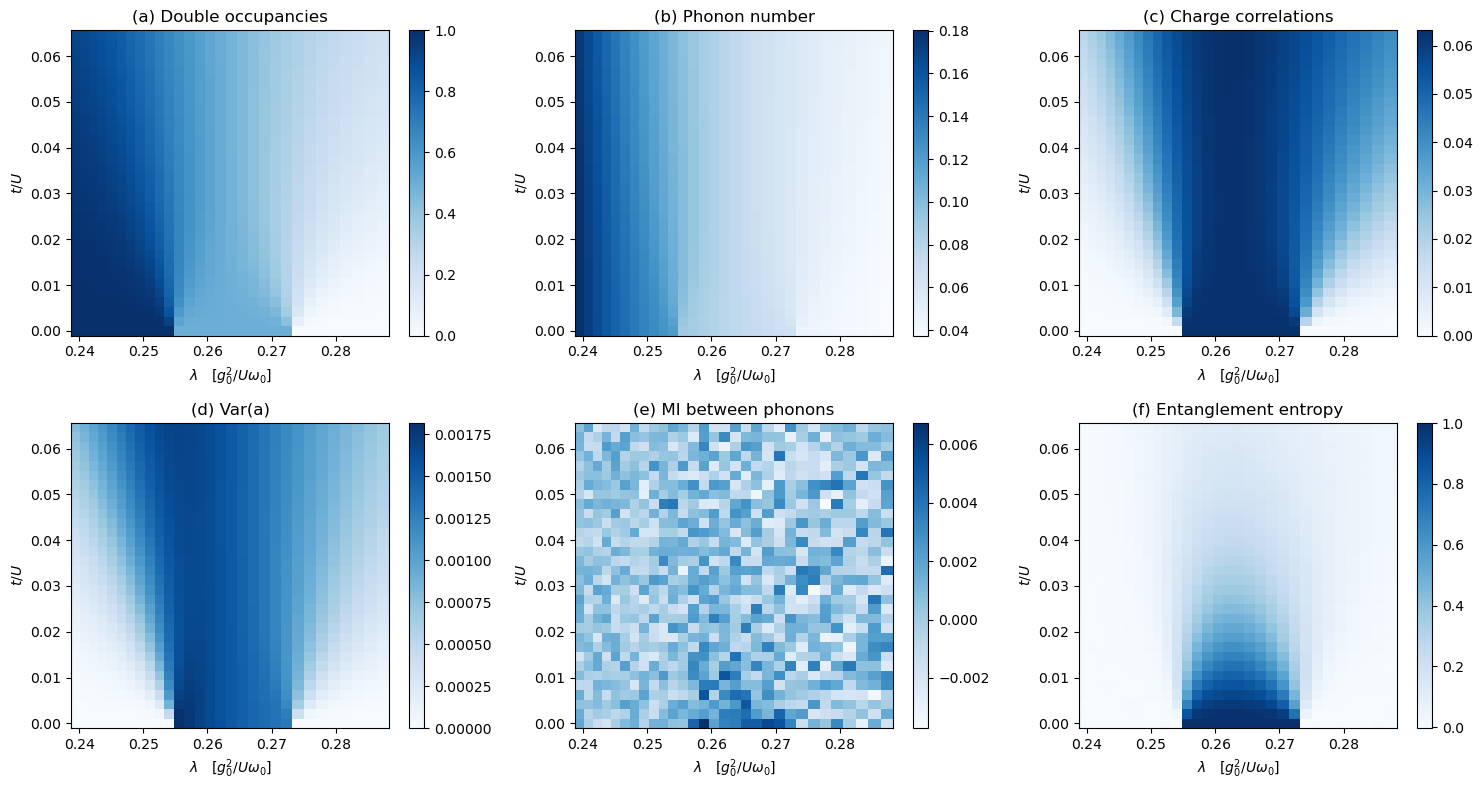

In [ ]:
# Create dummy data similar to your plots
from matplotlib.colors import LinearSegmentedColormap

lambda_s = 1 / (2.4 * (1 + o_s / 100))
lambda_s = lambda_s[::-1]  # Reverse for correct order            
t_s = t_s*20/2400
t_s = t_s[::-1]
X, Y = np.meshgrid(lambda_s, t_s)
colors = ["#DBE4FD", "#213FFF"]  # Blue → White
blue_white = LinearSegmentedColormap.from_list("blue_white", colors)
color= ['Blues']

# Create figure with subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# Plot 1
pcm1 = axs[0,0].pcolormesh(X, Y, double_occu_A, shading='auto', cmap=color[0])
fig.colorbar(pcm1, ax=axs[0,0])
axs[0,0].set_title("(a) Double occupancies")
axs[0,0].set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
axs[0,0].set_ylabel(r'$t/U$')

# Plot 2
pcm2 = axs[0,1].pcolormesh(X, Y, phonon_numb_A, shading='auto', cmap=color[0])
fig.colorbar(pcm2, ax=axs[0,1])
axs[0,1].set_title("(b) Phonon number")
axs[0,1].set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
axs[0,1].set_ylabel(r'$t/U$')

# Plot 3
pcm3 = axs[1,1].pcolormesh(X, Y, MI_phonons, shading='auto', cmap=color[0])
fig.colorbar(pcm3, ax=axs[1,1])
axs[1,1].set_title("(e) MI between phonons")
axs[1,1].set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
axs[1,1].set_ylabel(r'$t/U$')

# Plot 4
pcm4 = axs[1,2].pcolormesh(X, Y, Entangled_entropy, shading='auto', cmap=color[0])
fig.colorbar(pcm4, ax=axs[1,2])
axs[1,2].set_title("(f) Entanglement entropy")
axs[1,2].set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
axs[1,2].set_ylabel(r'$t/U$')

# Plot 5
pcm4 = axs[0,2].pcolormesh(X, Y, CC_single_tube_A, shading='auto', cmap=color[0])
fig.colorbar(pcm4, ax=axs[0,2])
axs[0,2].set_title("(c) Charge correlations")
axs[0,2].set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
axs[0,2].set_ylabel(r'$t/U$')

# Plot 6
pcm4 = axs[1,0].pcolormesh(X, Y, Var_pho_A, shading='auto', cmap=color[0])
fig.colorbar(pcm4, ax=axs[1,0])
axs[1,0].set_title("(d) Var(a)")
axs[1,0].set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
axs[1,0].set_ylabel(r'$t/U$')



# Improve layout
plt.tight_layout()

# Save to PDF
#fig.savefig("heatmaps.png", bbox_inches='tight')
plt.show()

In [15]:
# Save arrays
np.savez("allegutendatenzusammen.npz", 
         double_occu_A=double_occu_A, 
         double_occu_B=double_occu_B, 
         phonon_numb_A=phonon_numb_A, 
         phonon_numb_B=phonon_numb_B, 
         CC_single_tube_A=CC_single_tube_A, 
         CC_single_tube_B=CC_single_tube_B, 
         Var_pho_A=Var_pho_A,
         Var_pho_B=Var_pho_B,
         Entangled_entropy=Entangled_entropy,
         MI_phonons=MI_phonons, 
         negativity=negativity)